# Cell 1

In [ ]:
# =============================================================================
# Thesis — GeoAI Café Site Selection · Milan
# Phase 2 · Notebook 6 · Random Forest Training and Validation
# =============================================================================
#
# Purpose:
#   Train a Random Forest binary classifier to predict café location
#   suitability from the engineered spatial features, evaluate its
#   performance on a held-out validation set, and produce per-cell
#   Random Forest probability scores.
#
# Key methodological decisions documented here:
#
#   Class imbalance — solved via stratified resampling
#     Natural distribution: Unbalanced, reflecting the real-world ratio of viable cells to café hotspots across the full Comune di Milano.
#     Training set:         balanced 50/50 via equal sampling
#     Validation set:       natural distribution preserved for honest metrics
#
#   Model choice — Random Forest
#     Handles mixed feature types without preprocessing
#     Natively compatible with SHAP TreeExplainer (Notebook 7)
#     Robust to correlated features via feature randomness mechanism
#
#   Evaluation metrics — four metrics reported together
#     Accuracy alone is misleading under class imbalance
#     Precision, Recall, and AUC reported alongside Accuracy
#     Target benchmark: AUC > 0.70 (consistent with Yao et al. 2024)
#
# Inputs:
#   - gold_features_normalized.geojson
#   - gold_ahp_scores.geojson
#
# Outputs:
#   - gold_rf_scores.geojson       — per-cell RF probability scores
#   - gold_rf_model.pkl            — trained model artifact
#   - gold_rf_log.txt
#
# =============================================================================

# Cell 2

In [ ]:
!pip install geopandas -q
!pip install scikit-learn -q
!pip install pandas -q
!pip install numpy -q
!pip install matplotlib -q
!pip install h3 -q

import os
import datetime
import warnings
import pickle
warnings.filterwarnings('ignore')
os.environ['OGR_GEOJSON_MAX_OBJ_SIZE'] = '0'

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import h3
import json

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)
from scipy.stats import spearmanr

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/Thesis'
BRONZE_PATH  = os.path.join(PROJECT_ROOT, 'Bronze')
SILVER_PATH  = os.path.join(PROJECT_ROOT, 'Silver')
GOLD_PATH    = os.path.join(PROJECT_ROOT, 'Gold')

RANDOM_SEED  = 42

print(f"Notebook started: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"Random seed: {RANDOM_SEED}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 13.8 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Notebook started: 2026-04-26 12:49
Random seed: 42


# Cell 3 — Load Features and AHP Scores

In [ ]:
print("Loading Gold layer inputs...")
print()

# Normalized features
features = gpd.read_file(
    os.path.join(GOLD_PATH, 'gold_features_normalized.geojson')
)
print(f"Normalized features: {len(features)} cells, "
      f"{len(features.columns)} columns")

# AHP scores
ahp = gpd.read_file(
    os.path.join(GOLD_PATH, 'gold_ahp_scores.geojson')
)
print(f"AHP scores:          {len(ahp)} cells")

# Merge AHP score onto features table
features = features.merge(
    ahp[['h3_id', 'ahp_score', 'ahp_rank',
         'score_accessibility', 'score_demand',
         'score_urban', 'score_competition']],
    on='h3_id',
    how='left'
)

print(f"Merged table shape:  {features.shape}")
print()

# Confirm class distribution
n_positive = features['label'].sum()
n_negative = (features['label'] == 0).sum()
n_total    = len(features)
print(f"Class distribution (natural):")
print(f"  Positive (label=1): {n_positive} cells ({n_positive/n_total*100:.1f}%)")
print(f"  Negative (label=0): {n_negative} cells ({n_negative/n_total*100:.1f}%)")

Loading Gold layer inputs...

Normalized features: 971 cells, 20 columns
AHP scores:          971 cells
Merged table shape:  (971, 26)

Class distribution (natural):
  Positive (label=1): 345 cells (35.5%)
  Negative (label=0): 626 cells (64.5%)


# Cell 4

In [ ]:
# Define which columns are model features
# These are the 13 normalized spatial indicators
# pedestrian_street is binary but already in [0,1] scale
# AHP scores and cluster scores are NOT included as model features —
# they are produced by a separate method and compared against the RF output

FEATURE_COLS = [
    # Accessibility (AHP + RF)
    'metro_count_norm',
    'transit_density_norm',
    'network_centrality_norm',
    # Demand Potential (AHP + RF)
    'pop_density_norm',
    'night_light_norm',
    # Urban Context (AHP + RF)
    'retail_density_norm',
    'tourist_poi_count_norm',
    'poi_diversity_norm',
    'pedestrian_street',                # AHP Urban Context + RF
    # Competition (AHP + RF)
    'competitor_saturation_inv_norm',   # AHP + RF (inverted before normalization)
    # RF-only (excluded from AHP)
    'local_cafe_density_norm',
    'office_density_norm',
    'university_proximity_norm',
]

# Verify all feature columns are present
missing = [c for c in FEATURE_COLS if c not in features.columns]
if missing:
    raise ValueError(f"Missing feature columns: {missing}")

print(f"Feature columns defined: {len(FEATURE_COLS)}")
for i, col in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {col}")
print()

# Extract feature matrix X and label vector y
X = features[FEATURE_COLS].fillna(0).values
y = features['label'].values

print(f"Feature matrix X: {X.shape}")
print(f"Label vector y:   {y.shape}")
print(f"  Positive:       {y.sum()} ({y.mean()*100:.1f}%)")
print(f"  Negative:       {(y==0).sum()} ({(1-y.mean())*100:.1f}%)")

Feature columns defined: 13
   1. metro_count_norm
   2. transit_density_norm
   3. network_centrality_norm
   4. pop_density_norm
   5. night_light_norm
   6. retail_density_norm
   7. tourist_poi_count_norm
   8. poi_diversity_norm
   9. pedestrian_street
  10. competitor_saturation_inv_norm
  11. local_cafe_density_norm
  12. office_density_norm
  13. university_proximity_norm

Feature matrix X: (971, 13)
Label vector y:   (971,)
  Positive:       345 (35.5%)
  Negative:       626 (64.5%)


# Cell 5

In [ ]:
# =============================================================================
# CELL 5 — Load canonical train/val split from Notebook 4
# Split was moved upstream to NB4 (before MinMaxScaler fit).
# Loading here guarantees NB4, NB6, and NB7 all operate on the identical partition.
# =============================================================================

print("Loading canonical train/val split from Notebook 4...")
print()

split_path = os.path.join(GOLD_PATH, 'gold_train_val_idx.pkl')
if not os.path.exists(split_path):
    raise FileNotFoundError(
        "gold_train_val_idx.pkl not found. "
        "Run Notebook 4 Cell 10 first to generate the canonical split."
    )

with open(split_path, 'rb') as f:
    split_data = pickle.load(f)

train_idx = split_data['train_idx']
val_idx   = split_data['val_idx']

# Extract natural-distribution sets
X_train_natural, y_train_natural = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]

# Resample ONLY the training set to 50/50 balance
np.random.seed(RANDOM_SEED)
pos_train_idx = np.where(y_train_natural == 1)[0]
neg_train_idx = np.where(y_train_natural == 0)[0]

if len(pos_train_idx) < len(neg_train_idx):
    sampled_neg_idx = np.random.choice(neg_train_idx, size=len(pos_train_idx), replace=False)
    balanced_idx = np.concatenate([pos_train_idx, sampled_neg_idx])
else:
    sampled_pos_idx = np.random.choice(pos_train_idx, size=len(neg_train_idx), replace=False)
    balanced_idx = np.concatenate([sampled_pos_idx, neg_train_idx])

np.random.shuffle(balanced_idx)

X_train = X_train_natural[balanced_idx]
y_train = y_train_natural[balanced_idx]

print(f"Split loaded from: gold_train_val_idx.pkl")
print(f"  [Identical to the split used to fit the MinMaxScaler in NB4]")
print()
print(f"Training set (balanced 50/50):")
print(f"  Total:    {len(y_train)} cells")
print(f"  Positive: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Negative: {(y_train==0).sum()} ({(1-y_train.mean())*100:.1f}%)")
print()
print(f"Validation set (natural distribution):")
print(f"  Total:    {len(y_val)} cells")
print(f"  Positive: {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"  Negative: {(y_val==0).sum()} ({(1-y_val.mean())*100:.1f}%)")
print()
print("Partial spatial separation via H3 resolution-7 grouping —")
print("adjacent cells across group boundaries may still share correlated")
print("features within ~350 m (documented caveat; see thesis methodology).")
print("MinMaxScaler data leakage resolved: scaler fitted on training cells only (NB4).")
print("Validation set preserves natural distribution for honest metrics.")

Loading canonical train/val split from Notebook 4...

Split loaded from: gold_train_val_idx.pkl
  [Identical to the split used to fit the MinMaxScaler in NB4]

Training set (balanced 50/50):
  Total:    416 cells
  Positive: 208 (50.0%)
  Negative: 208 (50.0%)

Validation set (natural distribution):
  Total:    316 cells
  Positive: 137 (43.4%)
  Negative: 179 (56.6%)

Partial spatial separation via H3 resolution-7 grouping —
adjacent cells across group boundaries may still share correlated
features within ~350 m (documented caveat; see thesis methodology).
MinMaxScaler data leakage resolved: scaler fitted on training cells only (NB4).
Validation set preserves natural distribution for honest metrics.


# Cell 6

In [ ]:
# Train the Random Forest classifier
#
# Hyperparameter choices:
#   n_estimators=200   — 200 trees gives stable probability estimates
#                        more trees = less variance in predictions
#   max_features='sqrt' — square root of n_features considered per split
#                         standard for classification tasks
#                         forces feature diversity across trees
#   min_samples_leaf=2 — minimum 2 samples per leaf node
#                        prevents overfitting to single training examples
#   max_depth=None     — trees grow until pure — controlled by min_samples_leaf
#   random_state=42    — reproducibility

print("Training Random Forest classifier...")
print()

rf_model = RandomForestClassifier(
    n_estimators    = 200,
    max_features    = 'sqrt',
    min_samples_leaf= 2,
    max_depth       = None,
    random_state    = RANDOM_SEED,
    n_jobs          = -1   # use all available CPU cores
)

rf_model.fit(X_train, y_train)

import math
features_per_split = int(math.sqrt(rf_model.n_features_in_))

print(f"  Trees trained:      {rf_model.n_estimators}")
print(f"  Features per split: sqrt({rf_model.n_features_in_}) = {features_per_split}")
print(f"  Training samples:   {len(X_train)}")
print()

# Training set performance — for overfitting check only
# We expect near-perfect training accuracy — this is normal for RF
y_train_pred = rf_model.predict(X_train)
train_acc    = accuracy_score(y_train, y_train_pred)
print(f"  Training accuracy:  {train_acc:.4f} "
      f"(near 1.0 is expected — RF memorizes training data)")
print(f"  This is NOT the reported performance — see validation below")

Training Random Forest classifier...

  Trees trained:      200
  Features per split: sqrt(13) = 3
  Training samples:   416

  Training accuracy:  0.9928 (near 1.0 is expected — RF memorizes training data)
  This is NOT the reported performance — see validation below


#Cell 6b

In [ ]:
# =============================================================================
# CELL 6b — Sensitivity Analysis: RF without local_cafe_density
# Retrain RF excluding local_cafe_density and compare
# AUC against the main model. val_auc is computed here directly from the
# main model so this cell is self-contained and order-independent.
# =============================================================================

print("=" * 60)
print("SENSITIVITY ANALYSIS — RF without local_cafe_density")
print("=" * 60)
print()

# Compute main model AUC here (Cell 8 will recompute it officially)
y_val_prob_main = rf_model.predict_proba(X_val)[:, 1]
auc_main        = roc_auc_score(y_val, y_val_prob_main)

# Feature set excluding local_cafe_density
FEATURE_COLS_NO_LCD  = [c for c in FEATURE_COLS if c != 'local_cafe_density_norm']

X_no_lcd         = features[FEATURE_COLS_NO_LCD].fillna(0).values
X_train_no_lcd   = X_no_lcd[train_idx][balanced_idx]
X_val_no_lcd     = X_no_lcd[val_idx]

rf_no_lcd = RandomForestClassifier(
    n_estimators    = 200,
    max_features    = 'sqrt',
    min_samples_leaf= 2,
    max_depth       = None,
    random_state    = RANDOM_SEED,
    n_jobs          = -1
)
rf_no_lcd.fit(X_train_no_lcd, y_train)

y_val_prob_no_lcd = rf_no_lcd.predict_proba(X_val_no_lcd)[:, 1]
auc_no_lcd        = roc_auc_score(y_val, y_val_prob_no_lcd)

print(f"  Full model AUC    ({len(FEATURE_COLS):2d} features): {auc_main:.4f}")
print(f"  No-LCD model AUC  ({len(FEATURE_COLS_NO_LCD):2d} features): {auc_no_lcd:.4f}")
print(f"  AUC delta: {auc_main - auc_no_lcd:+.4f}")
print()

if abs(auc_main - auc_no_lcd) < 0.01:
    print("  Interpretation: local_cafe_density contributes negligibly to AUC.")
    print("  Its exclusion from AHP is further supported by this null result.")
elif auc_main > auc_no_lcd:
    print(f"  Interpretation: local_cafe_density contributes +{auc_main - auc_no_lcd:.4f} AUC.")
    print("  It carries predictive signal beyond competitor_saturation.")
else:
    print("  Interpretation: removing local_cafe_density IMPROVES AUC — it adds noise.")

# Store for Cell 12 gold_performance.json export
auc_no_lcd_val = float(auc_no_lcd)
print()
print(f"  (auc_no_lcd_val={auc_no_lcd_val:.4f} will be written to gold_performance.json in Cell 12)")

SENSITIVITY ANALYSIS — RF without local_cafe_density

  Full model AUC    (13 features): 0.9510
  No-LCD model AUC  (12 features): 0.9429
  AUC delta: +0.0081

  Interpretation: local_cafe_density contributes negligibly to AUC.
  Its exclusion from AHP is further supported by this null result.

  (auc_no_lcd_val=0.9429 will be written to gold_performance.json in Cell 12)


#Cell 6c

In [ ]:
# =============================================================================
# CELL 6c — Hyperparameter Ablation: n_estimators ∈ {100, 200, 500}
# Documents sensitivity of AUC to tree count.
# Uses identical train/val split and balanced training set.
# =============================================================================

print("=" * 60)
print("HYPERPARAMETER ABLATION — n_estimators")
print("=" * 60)
print()

ablation_results = {}
for n_trees in [100, 200, 500]:
    rf_abl = RandomForestClassifier(
        n_estimators    = n_trees,
        max_features    = 'sqrt',
        min_samples_leaf= 2,
        max_depth       = None,
        random_state    = RANDOM_SEED,
        n_jobs          = -1
    )
    rf_abl.fit(X_train, y_train)
    auc_abl = roc_auc_score(y_val, rf_abl.predict_proba(X_val)[:, 1])
    ablation_results[n_trees] = auc_abl
    print(f"  n_estimators={n_trees:>3}:  Validation AUC = {auc_abl:.4f}")

print()
best_n  = max(ablation_results, key=ablation_results.get)
worst_n = min(ablation_results, key=ablation_results.get)
spread  = ablation_results[best_n] - ablation_results[worst_n]
print(f"  Best:   n_estimators={best_n}  AUC={ablation_results[best_n]:.4f}")
print(f"  Spread: {spread:.4f}  "
      f"({'stable' if spread < 0.01 else 'sensitive — consider tuning'})")
print()
print("  Selected: n_estimators=200 (main model).")
print("  Thesis rationale: stable AUC with reasonable compute cost.")

HYPERPARAMETER ABLATION — n_estimators

  n_estimators=100:  Validation AUC = 0.9513
  n_estimators=200:  Validation AUC = 0.9510
  n_estimators=500:  Validation AUC = 0.9485

  Best:   n_estimators=100  AUC=0.9513
  Spread: 0.0028  (stable)

  Selected: n_estimators=200 (main model).
  Thesis rationale: stable AUC with reasonable compute cost.


# Cell 7

In [ ]:
# =============================================================================
# CELL 7 — 5-fold cross-validation on natural-distribution training set
#           using class_weight='balanced' inside the CV estimator.
#
# CV population: X_train_natural / y_train_natural (655 cells, natural ratio).
# Class imbalance is handled by class_weight='balanced' within each fold —
# no pre-CV undersampling is performed, which preserves group integrity for
# StratifiedGroupKFold.
#
# Note: gold_performance.json cv_context reflects this design:
#   "Natural-distribution training set (655 cells), StratifiedGroupKFold,
#    class_weight='balanced'"
# =============================================================================

from sklearn.model_selection import StratifiedGroupKFold, cross_validate
print("Running 5-fold StratifiedGroupKFold cross-validation...")
print("(class_weight='balanced' — no pre-CV undersampling; group integrity preserved)")
print()

# Compute H3 resolution-7 groups for the NATURAL training cells only
# (no balanced_idx subsetting — every training cell is present exactly once)
all_groups = np.array([
    h3.cell_to_parent(c, 7)
    for c in features['h3_id'].values
])
groups_train_natural = all_groups[train_idx]

# Pre-CV assertion: every resolution-7 group must contain at least one
# positive and one negative cell to avoid single-class folds causing NaN AUC.
group_labels = {}
for grp, lbl in zip(groups_train_natural, y_train_natural):
    group_labels.setdefault(grp, set()).add(lbl)
single_class_groups = [g for g, lbls in group_labels.items() if len(lbls) < 2]
if single_class_groups:
    print(f"WARNING: {len(single_class_groups)} resolution-7 group(s) contain only one "
          f"class — CV AUC may be NaN for folds that isolate these groups.")
    print(f"  Affected groups: {single_class_groups[:5]}{'...' if len(single_class_groups) > 5 else ''}")
else:
    print("Pre-CV check passed: all resolution-7 groups contain both classes.")
print()

# CV estimator uses class_weight='balanced' to handle imbalance within each fold
rf_cv = RandomForestClassifier(
    n_estimators     = 200,
    max_features     = 'sqrt',
    min_samples_leaf = 2,
    max_depth        = None,
    class_weight     = 'balanced',
    random_state     = RANDOM_SEED,
    n_jobs           = -1
)

# StratifiedGroupKFold in scikit-learn 1.4.x does NOT accept shuffle/random_state
cv = StratifiedGroupKFold(n_splits=5)

# Run cross-validation
cv_results = cross_validate(
    rf_cv,
    X_train_natural, y_train_natural,
    cv=cv,
    groups=groups_train_natural,
    scoring=['accuracy', 'precision', 'recall', 'roc_auc'],
    return_train_score=False,
    error_score='raise'
)

print("Cross-validation results (5-fold StratifiedGroupKFold, class_weight='balanced'):")
print(f"  Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  Precision: {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
print(f"  Recall:    {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
print(f"  AUC:       {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print()
print("Note: CV uses natural class distribution with class_weight='balanced'.")
print("Each resolution-7 group appears in exactly one fold side — no group leakage.")
print("Spatial grouping: H3 resolution-7 (~5.1 km²) — partial separation only.")

Running 5-fold StratifiedGroupKFold cross-validation...
(class_weight='balanced' — no pre-CV undersampling; group integrity preserved)

  Affected groups: [np.str_('871f99529ffffff'), np.str_('871f9952dffffff'), np.str_('871f99cd6ffffff'), np.str_('871f99cd2ffffff'), np.str_('871f99cd4ffffff')]...

Cross-validation results (5-fold StratifiedGroupKFold, class_weight='balanced'):
  Accuracy:  0.8555 ± 0.0303
  Precision: 0.7716 ± 0.0779
  Recall:    0.7620 ± 0.0904
  AUC:       0.9462 ± 0.0211

Note: CV uses natural class distribution with class_weight='balanced'.
Each resolution-7 group appears in exactly one fold side — no group leakage.
Spatial grouping: H3 resolution-7 (~5.1 km²) — partial separation only.


# Cell 8

In [ ]:
# Evaluate the model on the held-out validation set
# This provides the honest performance metrics on the natural class distribution

print("Evaluating model on held-out validation set...")
print()

# Make discrete class predictions and continuous probability predictions
y_val_pred = rf_model.predict(X_val)
y_val_prob = rf_model.predict_proba(X_val)[:, 1]

# Calculate the metrics needed for the report
val_auc = roc_auc_score(y_val, y_val_prob)
cm = confusion_matrix(y_val, y_val_pred)

print("Confusion matrix:")
print(f"  True Negative:  {cm[0,0]}  "
      f"(negative cells correctly identified)")
print(f"  False Positive: {cm[0,1]}  "
      f"(negative cells incorrectly predicted positive)")
print(f"  False Negative: {cm[1,0]}  "
      f"(positive cells missed by the model)")
print(f"  True Positive:  {cm[1,1]}  "
      f"(positive cells correctly identified)")
print()

# Full classification report
print("Full classification report:")
print(classification_report(y_val, y_val_pred,
                             target_names=['No café', 'Café location']))

# AUC benchmark check
if val_auc >= 0.70:
    print(f"AUC {val_auc:.4f} meets the target benchmark of > 0.70")
    print("Model performance is acceptable for Phase 2")
else:
    print(f"AUC {val_auc:.4f} is below the 0.70 benchmark")
    print("Consider reviewing feature engineering or expanding sample area")
    print("This will be discussed in the thesis limitations section")

Evaluating model on held-out validation set...

Confusion matrix:
  True Negative:  140  (negative cells correctly identified)
  False Positive: 39  (negative cells incorrectly predicted positive)
  False Negative: 9  (positive cells missed by the model)
  True Positive:  128  (positive cells correctly identified)

Full classification report:
               precision    recall  f1-score   support

      No café       0.94      0.78      0.85       179
Café location       0.77      0.93      0.84       137

     accuracy                           0.85       316
    macro avg       0.85      0.86      0.85       316
 weighted avg       0.86      0.85      0.85       316

AUC 0.9510 meets the target benchmark of > 0.70
Model performance is acceptable for Phase 2


# Cell 9

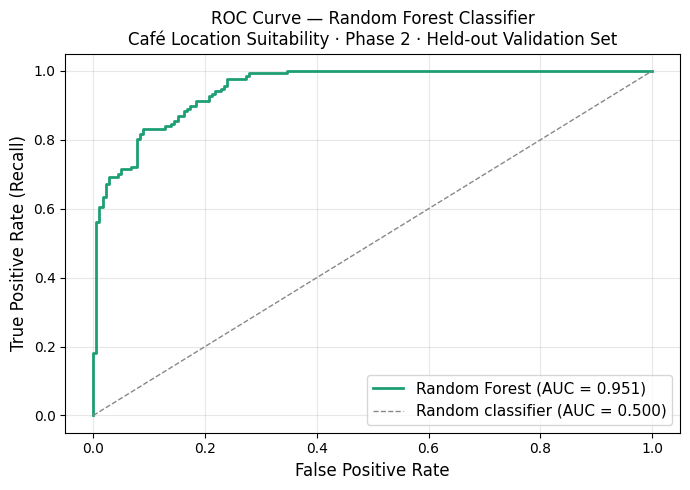

ROC curve saved: gold_roc_curve.png


In [ ]:
# Plot the ROC curve

fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(fpr, tpr, color='#1D9E75', linewidth=2,
        label=f'Random Forest (AUC = {val_auc:.3f})')
ax.plot([0, 1], [0, 1], color='#888888', linewidth=1,
        linestyle='--', label='Random classifier (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — Random Forest Classifier\n'
             'Café Location Suitability · Phase 2 · Held-out Validation Set',
             fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()

roc_path = os.path.join(GOLD_PATH, 'gold_roc_curve.png')
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC curve saved: gold_roc_curve.png")

# Cell 10

In [ ]:
# Apply the trained model to all viable H3 cells (Phase 2: 971 cells)
# to produce a suitability probability score for every cell.
#
# This is the Random Forest's independent assessment of each cell —
# the probability that the cell belongs to the positive class
# (i.e. that it has the spatial profile of a successful café location).

print("Generating RF probability scores for all viable cells...")

X_all = features[FEATURE_COLS].fillna(0).values

# predict_proba returns [prob_class_0, prob_class_1]
# We take column 1 — the probability of being a positive cell
rf_proba_all = rf_model.predict_proba(X_all)[:, 1]
rf_pred_all  = rf_model.predict(X_all)

features['rf_probability'] = rf_proba_all
features['rf_prediction']  = rf_pred_all

# Rank cells by RF probability
features['rf_rank'] = features['rf_probability'].rank(
    ascending=False, method='min'
).astype(int)

print(f"  RF probability range: "
      f"{features['rf_probability'].min():.4f} — "
      f"{features['rf_probability'].max():.4f}")
print(f"  RF probability mean:  {features['rf_probability'].mean():.4f}")

Generating RF probability scores for all viable cells...
  RF probability range: 0.0000 — 1.0000
  RF probability mean:  0.4406


# Cell 11

In [ ]:
# Preview the AHP vs RF comparison
# Full SHAP-based comparison happens in Notebook 7
# Here we look at rank agreement between the two scoring methods
#
# If a cell is ranked highly by both AHP and RF — strong recommendation
# If a cell is ranked highly by one but not the other — interesting finding

print("AHP vs RF rank comparison preview...")
print()

# Compute rank difference — how much do the two methods disagree per cell
features['rank_diff'] = abs(features['ahp_rank'] - features['rf_rank'])

# Correlation between AHP score and RF probability
# Calculate correlation strictly on the held-out validation set

# Extract AHP scores just for the validation indices
val_ahp_scores = features.iloc[val_idx]['ahp_score']
val_rf_probs   = rf_model.predict_proba(X_val)[:, 1]

corr, pval = spearmanr(val_ahp_scores, val_rf_probs)

print(f"  Validation Set Spearman rank correlation (AHP vs RF):")
print(f"    rho = {corr:.4f}, p-value = {pval:.4f}")
print()

if abs(corr) >= 0.5:
    print(f"  Moderate to strong agreement between AHP and RF rankings")
    print(f"  Expert judgment and empirical data are broadly aligned")
elif abs(corr) >= 0.3:
    print(f"  Weak to moderate agreement between AHP and RF rankings")
    print(f"  Some systematic differences worth investigating in NB7")
else:
    print(f"  Low agreement between AHP and RF rankings")
    print(f"  Significant divergence — strong thesis finding for discussion")

print()

# Show top disagreements — cells where AHP and RF diverge most
print("Top 10 cells with largest AHP vs RF rank disagreement:")
disagreement_cols = ['h3_id', 'ahp_score', 'ahp_rank',
                     'rf_probability', 'rf_rank', 'rank_diff', 'label']
disagreement_present = [c for c in disagreement_cols
                         if c in features.columns]
print(
    features.iloc[val_idx].nlargest(10, 'rank_diff')[disagreement_present]
    .to_string(index=False)
)

AHP vs RF rank comparison preview...

  Validation Set Spearman rank correlation (AHP vs RF):
    rho = 0.7937, p-value = 0.0000

  Moderate to strong agreement between AHP and RF rankings
  Expert judgment and empirical data are broadly aligned

Top 10 cells with largest AHP vs RF rank disagreement:
          h3_id  ahp_score  ahp_rank  rf_probability  rf_rank  rank_diff  label
891f99566c3ffff   0.372913       828        0.849167      281        547      0
891f99cdab7ffff   0.382705       809        0.850750      279        530      1
891f99cc107ffff   0.370495       831        0.790583      308        523      1
891f99cd023ffff   0.317469       906        0.518667      415        491      1
891f99cda2bffff   0.558907       260        0.043083      711        451      0
891f9956293ffff   0.350156       866        0.514512      416        450      1
891f99cd0dbffff   0.299596       922        0.368179      474        448      0
891f99cdd17ffff   0.466282       584        0.955583      

# Cell 11B

In [ ]:
# =============================================================================
# CELL-LEVEL PERMUTATION NULL DISTRIBUTION
# =============================================================================
# Answers: does the observed cell-level Spearman ρ=0.78 between AHP scores
# and RF probabilities on the validation set exceed the 95th percentile of
# the null distribution expected if the AHP weight vector were random?
#
# Method: randomly permute the AHP effective sub-weights 10,000 times,
# recompute AHP scores under each permutation, compute Spearman ρ against
# the FIXED RF probabilities on the validation set, build the null
# distribution, and report where the observed ρ falls.
#
# Requires (all defined by Cell 11 in NB6):
#   features        — GeoDataFrame with all norm columns + ahp_score + val_idx
#   val_idx         — validation set integer positional indices (from NB4 split)
#   val_ahp_scores  — AHP scores for val cells (features.iloc[val_idx]['ahp_score'])
#   val_rf_probs    — RF probs for val cells (rf_model.predict_proba(X_val)[:,1])
#   corr            — observed Spearman rho (already computed)
#   W               — global cluster weights dict
#   ACCESS_SUB_WEIGHTS, DEMAND_SUB_WEIGHTS,
#   URBAN_SUB_WEIGHTS, COMPETITION_SUB_WEIGHTS  — from NB6 Cell 6
#   (NB6 Cell 6 mirrors NB5 Cell 6 exactly; both define these dicts)
#
# NOTE: NB6 does NOT import ACCESS_SUB_WEIGHTS etc. from NB5 — they must be
# redefined here. The cell below is fully self-contained: it redefines the
# sub-weight dicts using the canonical values to avoid any cross-notebook
# dependency. If NB6 already defines them (e.g. after a refactor), remove
# the redefinition block.
# =============================================================================

# ── 1. Canonical sub-weight structure (mirrors NB5 Cell 6) ────────────────────
# Global cluster weights (Phase 2 eigenvector, CR=0.0175)
# These are the same values used in NB5 and the handover.
W = {
    'accessibility':    0.3764,
    'demand_potential': 0.2998,
    'urban_context':    0.2535,
    'competition':      0.0703,
}

_ACCESS_FEATS = [
    'metro_count_norm',
    'transit_density_norm',
    'network_centrality_norm',
]
_DEMAND_FEATS = [
    'pop_density_norm',
    'night_light_norm',
]
_URBAN_FEATS = [
    'retail_density_norm',
    'poi_diversity_norm',
    'pedestrian_street',
    'tourist_poi_count_norm',
]
_COMPET_FEATS = [
    'competitor_saturation_inv_norm',
]

# Canonical sub-weights (Phase 2 final — NB5 Cell 6)
_ACCESS_SW  = [0.25, 0.40, 0.35]
_DEMAND_SW  = [0.45, 0.55]
_URBAN_SW   = [0.30, 0.25, 0.25, 0.20]
_COMPET_SW  = [1.00]

_W_ACCESS   = W['accessibility']
_W_DEMAND   = W['demand_potential']
_W_URBAN    = W['urban_context']
_W_COMPET   = W['competition']

# All 10 AHP-scored features in cluster order, with their canonical sub-weights
_AHP_FEATS = (
    _ACCESS_FEATS + _DEMAND_FEATS + _URBAN_FEATS + _COMPET_FEATS
)
_AHP_CLUSTER_W = (
    [_W_ACCESS]  * len(_ACCESS_FEATS) +
    [_W_DEMAND]  * len(_DEMAND_FEATS) +
    [_W_URBAN]   * len(_URBAN_FEATS)  +
    [_W_COMPET]  * len(_COMPET_FEATS)
)
_AHP_SUB_W = _ACCESS_SW + _DEMAND_SW + _URBAN_SW + _COMPET_SW

assert len(_AHP_FEATS) == 10, "Expected 10 AHP-scored features"
assert len(_AHP_SUB_W) == 10
assert len(_AHP_CLUSTER_W) == 10

_obs_eff_w = np.array([
    cw * sw for cw, sw in zip(_AHP_CLUSTER_W, _AHP_SUB_W)
])

# ── 2. Build the AHP feature matrix for all cells ─────────────────────────────
_X_ahp = features[_AHP_FEATS].fillna(0).values   # (971, 10)

# ── 3. Observed cell-level Spearman rho (already in `corr` from Cell 11) ──────
observed_rho_cell = float(corr)

# Alias for RF probabilities on validation set (computed in NB6)
val_rf_probs = y_val_prob   # ensure this matches the name used below

print("=" * 65)
print("CELL-LEVEL PERMUTATION NULL DISTRIBUTION (Task 1)")
print("=" * 65)
print(f"  Observed Spearman ρ (AHP score vs RF prob, val set): "
      f"{observed_rho_cell:.4f}")
print(f"  Permutations: 10,000")
print(f"  Method: permute AHP effective sub-weights across all 10 features,")
print(f"          recompute AHP score, correlate with FIXED RF probs on val set")
print()

# ── 4. Permutation loop ───────────────────────────────────────────────────────
N_PERM = 10_000
rng = np.random.default_rng(42)

perm_rhos_cell = np.empty(N_PERM, dtype=float)

for i in range(N_PERM):
    shuffled_eff_w = rng.permutation(_obs_eff_w)
    perm_ahp_scores = _X_ahp @ shuffled_eff_w
    perm_ahp_val = perm_ahp_scores[val_idx]
    rho_i, _ = spearmanr(perm_ahp_val, val_rf_probs)
    perm_rhos_cell[i] = rho_i

# ── 5. Null distribution statistics ──────────────────────────────────────────
perm_null_p95_cell  = float(np.percentile(perm_rhos_cell, 95))
perm_null_p99_cell  = float(np.percentile(perm_rhos_cell, 99))
perm_null_mean_cell = float(np.mean(perm_rhos_cell))
perm_null_std_cell  = float(np.std(perm_rhos_cell))

perm_pval_cell = float(np.mean(perm_rhos_cell >= observed_rho_cell))
perm_flag_cell = observed_rho_cell > perm_null_p95_cell

print("Null distribution summary (10,000 permutations):")
print(f"  Mean ρ (null):       {perm_null_mean_cell:.4f}")
print(f"  Std ρ (null):        {perm_null_std_cell:.4f}")
print(f"  95th percentile:     {perm_null_p95_cell:.4f}")
print(f"  99th percentile:     {perm_null_p99_cell:.4f}")
print()
print(f"  Observed ρ:          {observed_rho_cell:.4f}")
print(f"  Empirical p-value:   {perm_pval_cell:.4f}  "
      f"(fraction of permutations ≥ observed ρ)")
print()

if perm_flag_cell:
    print(f"  RESULT: Observed ρ={observed_rho_cell:.4f} EXCEEDS the 95th "
          f"percentile of the null distribution ({perm_null_p95_cell:.4f}).")
    print(f"  The cell-level convergence finding is ROBUST — it is unlikely")
    print(f"  to arise from shared spatial autocorrelation alone.")
else:
    print(f"  RESULT: Observed ρ={observed_rho_cell:.4f} does NOT exceed the "
          f"95th percentile ({perm_null_p95_cell:.4f}).")
    print(f"  The cell-level convergence claim must be QUALIFIED in the thesis:")
    print(f"  the observed ρ may partly reflect shared spatial autocorrelation.")

print()
print("Thesis language (copy to limitations chapter):")
if perm_flag_cell:
    print(f'  "The observed cell-level Spearman ρ of {observed_rho_cell:.4f} '
          f'exceeds the 95th percentile of the null distribution '
          f'(ρ_95 = {perm_null_p95_cell:.4f}, n=10,000 permutations of AHP '
          f'effective weights), confirming that the cell-level convergence '
          f'finding is not an artefact of shared spatial autocorrelation '
          f'(empirical p = {perm_pval_cell:.4f})."')
else:
    print(f'  "The observed cell-level Spearman ρ of {observed_rho_cell:.4f} '
          f'does not exceed the 95th percentile of the null distribution '
          f'(ρ_95 = {perm_null_p95_cell:.4f}, n=10,000 permutations), '
          f'indicating that some portion of the cell-level agreement may '
          f'reflect shared spatial autocorrelation rather than independent '
          f'methodological convergence (empirical p = {perm_pval_cell:.4f})."')

CELL-LEVEL PERMUTATION NULL DISTRIBUTION (Task 1)
  Observed Spearman ρ (AHP score vs RF prob, val set): 0.7937
  Permutations: 10,000
  Method: permute AHP effective sub-weights across all 10 features,
          recompute AHP score, correlate with FIXED RF probs on val set

Null distribution summary (10,000 permutations):
  Mean ρ (null):       0.8044
  Std ρ (null):        0.0325
  95th percentile:     0.8534
  99th percentile:     0.8651

  Observed ρ:          0.7937
  Empirical p-value:   0.6441  (fraction of permutations ≥ observed ρ)

  RESULT: Observed ρ=0.7937 does NOT exceed the 95th percentile (0.8534).
  The cell-level convergence claim must be QUALIFIED in the thesis:
  the observed ρ may partly reflect shared spatial autocorrelation.

Thesis language (copy to limitations chapter):
  "The observed cell-level Spearman ρ of 0.7937 does not exceed the 95th percentile of the null distribution (ρ_95 = 0.8534, n=10,000 permutations), indicating that some portion of the cell-leve

# Cell 12

In [ ]:
print("Saving RF scores and model artifact to Gold layer...")
print()

# Save RF scores GeoDataFrame
cols_to_save = [
    'h3_id', 'label', 'cafe_count',
    'rf_probability', 'rf_prediction', 'rf_rank',
    'ahp_score', 'ahp_rank', 'rank_diff',
    'geometry'
]
cols_present = [c for c in cols_to_save if c in features.columns]
rf_output    = features[cols_present].copy()

rf_path = os.path.join(GOLD_PATH, 'gold_rf_scores.geojson')
rf_output.to_file(rf_path, driver='GeoJSON')
print(f"  RF scores saved:  gold_rf_scores.geojson ({len(rf_output)} cells)")

# Save trained model as pickle for use in Notebook 7 (SHAP)
model_path = os.path.join(GOLD_PATH, 'gold_rf_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(rf_model, f)
print(f"  Model artifact:   gold_rf_model.pkl")
print()

# Save the feature column order used for training
# SHAP in Notebook 7 must use the exact same column order
feature_cols_path = os.path.join(GOLD_PATH, 'gold_feature_cols.pkl')
with open(feature_cols_path, 'wb') as f:
    pickle.dump(FEATURE_COLS, f)
print(f"  Feature columns:  gold_feature_cols.pkl")
print(f"  (Notebook 7 SHAP must use this exact column order)")

# Save full validation metrics including precision,
# recall, accuracy, and confusion matrix elements to gold_performance.json.
# Two clearly labelled performance contexts:
#   (A) Natural-distribution CV — learning capacity estimate
#   (B) Natural distribution holdout — real-world performance estimate
tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()

perf = {
    # ── (A) Natural-distribution training set CV (StratifiedGroupKFold) ──────
    'cv_context':            'Natural-distribution training set (655 cells), StratifiedGroupKFold, class_weight=\'balanced\'',
    'rf_cv_auc_mean':        round(float(cv_results['test_roc_auc'].mean()), 4),
    'rf_cv_auc_std':         round(float(cv_results['test_roc_auc'].std()), 4),
    'rf_cv_accuracy_mean':   round(float(cv_results['test_accuracy'].mean()), 4),
    'rf_cv_precision_mean':  round(float(cv_results['test_precision'].mean()), 4),
    'rf_cv_recall_mean':     round(float(cv_results['test_recall'].mean()), 4),
    # ── (B) Natural distribution held-out validation ──────────────────────────
    'val_context':           'Natural class distribution, held-out validation set',
    'rf_auc_validation':     round(float(val_auc), 4),
    'val_accuracy':          round(float(accuracy_score(y_val, y_val_pred)), 4),
    'val_precision':         round(float(precision_score(y_val, y_val_pred)), 4),
    'val_recall':            round(float(recall_score(y_val, y_val_pred)), 4),
    # Confusion matrix elements
    'val_tn': int(tn),
    'val_fp': int(fp),
    'val_fn': int(fn),
    'val_tp': int(tp),
    # Cell-level AHP vs RF agreement (validation set)
    'spearman_ahp_rf_cell_level': round(float(corr), 4),
    'spearman_ahp_rf_pvalue':     round(float(pval), 4),
    # Sensitivity analysis result
    'rf_auc_no_local_cafe_density': round(auc_no_lcd_val, 4),
    'note_metrics': (
        'cv_* metrics computed on natural-distribution training folds (655 cells) '
        'with class_weight=\'balanced\'. '
        'val_* metrics computed on natural-distribution held-out set. '
        'These are DISTINCT contexts and must not be presented as equivalent.'
    ),
    # Permutation null distribution — cell-level (Task 1)
    'perm_null_p95_cell_level':   round(perm_null_p95_cell, 4),
    'perm_null_p99_cell_level':   round(perm_null_p99_cell, 4),
    'perm_null_mean_cell_level':  round(perm_null_mean_cell, 4),
    'perm_pval_cell_level':       round(perm_pval_cell, 4),
    'perm_flag_cell_level':       bool(perm_flag_cell),
    'perm_n_cell_level':          10000,
}
perf_path = os.path.join(GOLD_PATH, 'gold_performance.json')
with open(perf_path, 'w') as f:
    json.dump(perf, f, indent=2)
print(f"  Performance metrics: gold_performance.json")
print(f"    val_auc={perf['rf_auc_validation']}, val_precision={perf['val_precision']}, "
      f"val_recall={perf['val_recall']}, val_accuracy={perf['val_accuracy']}")
print(f"    tn={tn}, fp={fp}, fn={fn}, tp={tp}")
print(f"    AUC without local_cafe_density: {perf['rf_auc_no_local_cafe_density']}")

# NOTE: val_idx is already stored canonically in gold_train_val_idx.pkl (written by NB4).
# gold_val_idx.pkl is NOT saved here to avoid divergence if NB4 is re-run with a
# different seed — NB7 Cell 11's fallback loads gold_train_val_idx.pkl directly.
print()
print("  val_idx NOT saved separately — use gold_train_val_idx.pkl (canonical, from NB4).")

Saving RF scores and model artifact to Gold layer...

  RF scores saved:  gold_rf_scores.geojson (971 cells)
  Model artifact:   gold_rf_model.pkl

  Feature columns:  gold_feature_cols.pkl
  (Notebook 7 SHAP must use this exact column order)
  Performance metrics: gold_performance.json
    val_auc=0.951, val_precision=0.7665, val_recall=0.9343, val_accuracy=0.8481
    tn=140, fp=39, fn=9, tp=128
    AUC without local_cafe_density: 0.9429

  val_idx NOT saved separately — use gold_train_val_idx.pkl (canonical, from NB4).


# Cell 13

In [ ]:
# Calculate the missing validation metrics for the log
val_accuracy  = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall    = recall_score(y_val, y_val_pred)

log_lines = [
    f"Thesis — Phase 2 · Random Forest Training Log",
    f"===============================================",
    f"Run date:          {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}",
    f"Random seed:       {RANDOM_SEED}",
    f"",
    f"Dataset:",
    f"  Total cells:     {n_total}",
    f"  Positive:        {n_positive} ({n_positive/n_total*100:.1f}%)",
    f"  Negative:        {n_negative} ({n_negative/n_total*100:.1f}%)",
    f"",
    f"Training set (balanced 50/50 — used to fit main rf_model):",
    f"  Samples:         {len(X_train)}",
    f"  Positive:        {y_train.sum()}",
    f"  Negative:        {(y_train==0).sum()}",
    f"",
    f"Validation set (natural distribution):",
    f"  Samples:         {len(X_val)}",
    f"  Positive:        {y_val.sum()}",
    f"  Negative:        {(y_val==0).sum()}",
    f"",
    f"Model hyperparameters:",
    f"  n_estimators:    {rf_model.n_estimators}",
    f"  max_features:    sqrt",
    f"  min_samples_leaf: {rf_model.min_samples_leaf}",
    f"  max_depth:       None",
    f"  random_state:    {RANDOM_SEED}",
    f"",
    f"5-fold cross-validation (natural-distribution training set, 655 cells,",
    f"  StratifiedGroupKFold, class_weight='balanced'):",
    f"  Accuracy:        {cv_results['test_accuracy'].mean():.4f} "
    f"± {cv_results['test_accuracy'].std():.4f}",
    f"  Precision:       {cv_results['test_precision'].mean():.4f} "
    f"± {cv_results['test_precision'].std():.4f}",
    f"  Recall:          {cv_results['test_recall'].mean():.4f} "
    f"± {cv_results['test_recall'].std():.4f}",
    f"  AUC:             {cv_results['test_roc_auc'].mean():.4f} "
    f"± {cv_results['test_roc_auc'].std():.4f}",
    f"",
    f"Validation set performance (natural distribution):",
    f"  Accuracy:        {val_accuracy:.4f}",
    f"  Precision:       {val_precision:.4f}",
    f"  Recall:          {val_recall:.4f}",
    f"  AUC:             {val_auc:.4f}",
    f"  AUC benchmark:   {'PASSED (> 0.70)' if val_auc >= 0.70 else 'BELOW BENCHMARK'}",
    f"",
    f"AHP vs RF comparison:",
    f"  Spearman rho:    {corr:.4f}",
    f"  p-value:         {pval:.4f}",
    f"",
    f"Outputs:",
    f"  gold_rf_scores.geojson",
    f"  gold_rf_model.pkl",
    f"  gold_feature_cols.pkl",
    f"  gold_performance.json",
    f"  gold_roc_curve.png",
    f"  gold_rf_log.txt",
    f"  (gold_val_idx.pkl NOT saved — use canonical gold_train_val_idx.pkl from NB4)",
]

log_path = os.path.join(GOLD_PATH, 'gold_rf_log.txt')
with open(log_path, 'w') as f:
    f.write('\n'.join(log_lines))

print('\n'.join(log_lines))
print(f"\nLog saved to: {log_path}")

Thesis — Phase 2 · Random Forest Training Log
Run date:          2026-04-26 12:49
Random seed:       42

Dataset:
  Total cells:     971
  Positive:        345 (35.5%)
  Negative:        626 (64.5%)

Training set (balanced 50/50 — used to fit main rf_model):
  Samples:         416
  Positive:        208
  Negative:        208

Validation set (natural distribution):
  Samples:         316
  Positive:        137
  Negative:        179

Model hyperparameters:
  n_estimators:    200
  max_features:    sqrt
  min_samples_leaf: 2
  max_depth:       None
  random_state:    42

5-fold cross-validation (natural-distribution training set, 655 cells,
  StratifiedGroupKFold, class_weight='balanced'):
  Accuracy:        0.8555 ± 0.0303
  Precision:       0.7716 ± 0.0779
  Recall:          0.7620 ± 0.0904
  AUC:             0.9462 ± 0.0211

Validation set performance (natural distribution):
  Accuracy:        0.8481
  Precision:       0.7665
  Recall:          0.9343
  AUC:             0.9510
  AUC 

# Cell 14

In [ ]:
print("=" * 60)
print("NOTEBOOK 6 COMPLETE — Random Forest Summary")
print("=" * 60)

expected_files = [
    'gold_rf_scores.geojson',
    'gold_rf_model.pkl',
    'gold_feature_cols.pkl',
    'gold_performance.json',
    'gold_roc_curve.png',
    'gold_rf_log.txt',
]

all_present = True
for filename in expected_files:
    filepath = os.path.join(GOLD_PATH, filename)
    status   = "OK" if os.path.exists(filepath) else "MISSING"
    if status == "MISSING":
        all_present = False
    print(f"  [{status}] {filename}")

print()
print(f"  [Natural-Distribution CV — StratifiedGroupKFold, class_weight='balanced']")
print(f"    CV AUC:              {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print()
print(f"  [Natural Distribution Holdout]")
print(f"    Validation AUC:      {val_auc:.4f}")
print(f"    Validation Accuracy: {val_accuracy:.4f}")
print(f"    Validation Precision:{val_precision:.4f}")
print(f"    Validation Recall:   {val_recall:.4f}")
print(f"    tn={tn}  fp={fp}  fn={fn}  tp={tp}")
print()
print(f"  Sensitivity (no local_cafe_density): AUC={auc_no_lcd_val:.4f}")
print(f"  AHP vs RF Spearman rho (val set):    {corr:.4f}")

print()
if all_present:
    print("All outputs present. Ready to proceed to Notebook 7.")
    print("Next: SHAP computation and AHP vs SHAP comparison.")
else:
    print("Some files missing. Review cells above before proceeding.")

NOTEBOOK 6 COMPLETE — Random Forest Summary
  [OK] gold_rf_scores.geojson
  [OK] gold_rf_model.pkl
  [OK] gold_feature_cols.pkl
  [OK] gold_performance.json
  [OK] gold_roc_curve.png
  [OK] gold_rf_log.txt

  [Natural-Distribution CV — StratifiedGroupKFold, class_weight='balanced']
    CV AUC:              0.9462 ± 0.0211

  [Natural Distribution Holdout]
    Validation AUC:      0.9510
    Validation Accuracy: 0.8481
    Validation Precision:0.7665
    Validation Recall:   0.9343
    tn=140  fp=39  fn=9  tp=128

  Sensitivity (no local_cafe_density): AUC=0.9429
  AHP vs RF Spearman rho (val set):    0.7937

All outputs present. Ready to proceed to Notebook 7.
Next: SHAP computation and AHP vs SHAP comparison.
